In [1]:
import torch

from pprint import pprint

from decoder_patching import (
    decode_from_encoder_output,
    get_encoder_output,
    load_mask_predict_context,
    plot_layerwise_token_mask_heatmap,
    plot_token_mask_probs,
    run_decoder_layer_sweep_experiment,
    run_decoder_patching_experiment,
)
from utils import REPO_ROOT, preprocess_mask_predict_data, trace_mask_predict_iterations

In [2]:
prep_result = preprocess_mask_predict_data(
    input_dir=REPO_ROOT / "input",
    output_dir=REPO_ROOT / "output",
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    run_name="en_de_demo",
    workers=10,
)

In [3]:
trace_result = trace_mask_predict_iterations(
    data_bin_dir=prep_result["data_bin_dir"],
    output_dir=REPO_ROOT / "output",
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    subset="test",
    run_name="en_de_demo",
    decoding_iterations=5,
    length_beam=5,
    max_sentences=20,
)

for record in trace_result["records"]:
    print(f"[{record['id']}]")
    print("src:", record["source"])
    print("tgt:", record["target"])
    print("hyp:", record["hypothesis"])
    print("iterations:")
    for step in record["iterations"]:
        print(f"iter {step['iteration']:02d} (masked={step['masked_tokens']:>2}): {step['text']}")


[0]
src: The capital of France is Paris .
tgt: Die Hauptstadt Frankreichs ist Paris .
hyp: Die Hauptstadt Frankreichs ist Paris .
iterations:
iter 00 (masked= 0): Die Hauptstadt Frankreichs ist Paris .
iter 01 (masked= 5): Die Hauptstadt Frankreichs ist Paris .
iter 02 (masked= 4): Die Hauptstadt Frankreichs ist Paris .
iter 03 (masked= 2): Die Hauptstadt Frankreichs ist Paris .
iter 04 (masked= 1): Die Hauptstadt Frankreichs ist Paris .
[1]
src: The capital of Germany is Berlin .
tgt: Die Hauptstadt Deutschlands ist Berlin .
hyp: Die Hauptstadt Deutschlands ist Berlin .
iterations:
iter 00 (masked= 0): Die Hauptstadt Deutschlands ist Berlin .
iter 01 (masked= 5): Die Hauptstadt Deutschlands ist Berlin .
iter 02 (masked= 4): Die Hauptstadt Deutschlands ist Berlin .
iter 03 (masked= 2): Die Hauptstadt Deutschlands ist Berlin .
iter 04 (masked= 1): Die Hauptstadt Deutschlands ist Berlin .
[2]
src: China is a large country in Asia , and the capital of the country is Beijing .
tgt: China i

In [4]:
state = torch.load("./checkpoints/maskPredict_en_de/checkpoint_best.pt", map_location="cpu", weights_only=False)
model_args = state["args"]

for k in [
    "arch",
    "encoder_layers",
    "encoder_embed_dim",
    "encoder_ffn_embed_dim",
    "encoder_attention_heads",
    "decoder_layers",
    "decoder_embed_dim",
    "decoder_ffn_embed_dim",
    "decoder_attention_heads",
]:
    if hasattr(model_args, k):
        print(k, "=", getattr(model_args, k))


arch = bert_transformer_seq2seq
encoder_layers = 6
encoder_embed_dim = 512
encoder_ffn_embed_dim = 2048
encoder_attention_heads = 8
decoder_layers = 6
decoder_embed_dim = 512
decoder_ffn_embed_dim = 2048
decoder_attention_heads = 8


In [5]:
context = load_mask_predict_context(
    data_bin_dir=prep_result["data_bin_dir"],
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    decoding_iterations=5,
    length_beam=1,
    max_sentences=20,
    use_cpu=True,
)

In [6]:
encoder_example = get_encoder_output(
    "China is a large country in Asia , and the capital of the country is Beijing .",
    context,
)

print("sentence:", encoder_example["sentence"])
print("src_tokens shape:", tuple(encoder_example["src_tokens"].shape))
print("src_lengths:", encoder_example["src_lengths"].tolist())
print("predicted target length:", int(encoder_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))

sentence: China is a large country in Asia , and the capital of the country is Beijing .
src_tokens shape: (1, 18)
src_lengths: [18]
predicted target length: 16


In [7]:
patch_src_sentence = "The bank was steep beside the stream ."
patch_tgt_sentence = "The bank was open beside the market ."

patch_src = get_encoder_output(patch_src_sentence, context)
patch_tgt = get_encoder_output(patch_tgt_sentence, context)

In [8]:
print("patch source sentence:", patch_src["sentence"])
print("patch target sentence:", patch_tgt["sentence"])
src_dict = context["task"].source_dictionary
patch_src_token_ids = patch_src["src_tokens"][0].tolist()
patch_tgt_token_ids = patch_tgt["src_tokens"][0].tolist()
patch_src_token_text = [src_dict[token_id] for token_id in patch_src_token_ids]
patch_tgt_token_text = [src_dict[token_id] for token_id in patch_tgt_token_ids]
print("patch source encoder_out shape:", tuple(patch_src["encoder_out"]["encoder_out"].shape))
print("patch target encoder_out shape:", tuple(patch_tgt["encoder_out"]["encoder_out"].shape))
print("patch source token ids:", [patch_src_token_ids])
print("patch source token texts:", patch_src_token_text)
print("patch source token pairs:", list(zip(patch_src_token_ids, patch_src_token_text)))
print("patch target token ids:", [patch_tgt_token_ids])
print("patch target token texts:", patch_tgt_token_text)
print("patch target token pairs:", list(zip(patch_tgt_token_ids, patch_tgt_token_text)))
print("patch source predicted target length:", int(patch_src["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))
print("patch target predicted target length:", int(patch_tgt["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))

patch source sentence: The bank was steep beside the stream .
patch target sentence: The bank was open beside the market .
patch source encoder_out shape: (9, 1, 512)
patch target encoder_out shape: (9, 1, 512)
patch source token ids: [[30, 2711, 66, 23863, 20645, 7, 9925, 6, 2]]
patch source token texts: ['The', 'bank', 'was', 'steep', 'beside', 'the', 'stream', '.', '</s>']
patch source token pairs: [(30, 'The'), (2711, 'bank'), (66, 'was'), (23863, 'steep'), (20645, 'beside'), (7, 'the'), (9925, 'stream'), (6, '.'), (2, '</s>')]
patch target token ids: [[30, 2711, 66, 861, 20645, 7, 375, 6, 2]]
patch target token texts: ['The', 'bank', 'was', 'open', 'beside', 'the', 'market', '.', '</s>']
patch target token pairs: [(30, 'The'), (2711, 'bank'), (66, 'was'), (861, 'open'), (20645, 'beside'), (7, 'the'), (375, 'market'), (6, '.'), (2, '</s>')]
patch source predicted target length: 9
patch target predicted target length: 9


In [9]:
layer_index = 2

source_predicted_length = int(patch_src["encoder_out"]["predicted_lengths"].argmax(dim=-1).item())
target_predicted_length = int(patch_tgt["encoder_out"]["predicted_lengths"].argmax(dim=-1).item())

print("decoder layer index:", layer_index)
print("patch mode:", "full_layer")
print("source predicted target length:", source_predicted_length)
print("target predicted target length:", target_predicted_length)
print("full layer patch requires matching lengths:", source_predicted_length == target_predicted_length)

decoder layer index: 2
patch mode: full_layer
source predicted target length: 9
target predicted target length: 9
full layer patch requires matching lengths: True


In [10]:
decoded_original_tgt = decode_from_encoder_output(
    patch_tgt["encoder_out"],
    context=context,
    decoding_iterations=5,
)

decoder_patch_result = run_decoder_patching_experiment(
    donor_sentence=patch_src_sentence,
    base_sentence=patch_tgt_sentence,
    context=context,
    layer_index=layer_index,
    decoding_iterations=5,
)

In [11]:
print("source sentence:", patch_src_sentence)
print("target sentence:", patch_tgt_sentence)
print("decoded from original target encoder:", decoded_original_tgt["decoded_text"])
print("decoded from decoder-patched target:", decoder_patch_result["decoded_text"])
print()
print("patched decoder iteration trace:")
for step in decoder_patch_result["iteration_trace"]:
    print(f"iter {step['iteration']:02d}: {step['text']}")
    print("  selected mask tokens:", step["selected_mask_tokens"])
    print("  selected mask probs:", step["selected_mask_probs"])
    print("  token mask probs:", step["token_mask_probs"])

source sentence: The bank was steep beside the stream .
target sentence: The bank was open beside the market .
decoded from original target encoder: Die Bank war neben dem Markt offen .
decoded from decoder-patched target: Die Bank war offen neben dem Markt .

patched decoder iteration trace:
iter 00: Die Bank war neben dem Markt Markt .
  selected mask tokens: []
  selected mask probs: []
  token mask probs: [0.145222, 0.042573, 0.161405, 0.10253, 0.339412, 0.158917, 0.455182, 0.101093, 0.088161]
iter 01: Die Bank war offen neben dem Markt .
  selected mask tokens: ['Markt', 'dem', 'war', 'Markt', 'Die', 'neben', '.']
  selected mask probs: [0.455182, 0.339412, 0.161405, 0.158917, 0.145222, 0.10253, 0.101093]
  token mask probs: [0.098377, 0.042573, 0.098778, 0.327061, 0.066347, 0.142429, 0.077642, 0.099391, 0.088161]
iter 02: Die Bank war offen neben dem Markt .
  selected mask tokens: ['offen', 'dem', '.', 'war', 'Die']
  selected mask probs: [0.327061, 0.142429, 0.099391, 0.098778,

In [12]:
print("decoder patch activation trace:")
for step in decoder_patch_result["patch_trace"]:
    print(f"iter {step['iteration']:02d}:")
    print("  patch mode:", step["patch_mode"])
    print("  activation shape:", step["activation_shape"])
    print("  source text:", step["donor_text"])
    print("  patched text:", step["patched_text"])
    print("  source activation norm:", step["donor_activation_norm"])
    print("  target activation norm before patch:", step["base_activation_norm_before_patch"])
    print("  target activation norm after patch:", step["base_activation_norm_after_patch"])


decoder patch activation trace:
iter 00:
  patch mode: full_layer
  activation shape: [9, 1, 512]
  source text: Die Ufer war steil neben Fluss Fluss .
  patched text: Die Bank war neben dem Markt Markt .
  source activation norm: 32.571114
  target activation norm before patch: 32.15913
  target activation norm after patch: 32.571114
iter 01:
  patch mode: full_layer
  activation shape: [9, 1, 512]
  source text: Die Ufer war steil neben dem Fluss .
  patched text: Die Bank war offen neben dem Markt .
  source activation norm: 31.675554
  target activation norm before patch: 31.245686
  target activation norm after patch: 31.675554
iter 02:
  patch mode: full_layer
  activation shape: [9, 1, 512]
  source text: Die Ufer war steil neben dem Fluss .
  patched text: Die Bank war offen neben dem Markt .
  source activation norm: 31.350994
  target activation norm before patch: 30.327475
  target activation norm after patch: 31.350994
iter 03:
  patch mode: full_layer
  activation shape: [

In [13]:
final_predicted_sentence = decoder_patch_result["decoded_text"]
print("final predicted sentence:", final_predicted_sentence)

final predicted sentence: Die Bank war offen neben dem Markt .


In [14]:
pprint(decoder_patch_result["patch_trace"][-1])

{'activation_shape': [9, 1, 512],
 'base_activation_norm_after_patch': 30.033749,
 'base_activation_norm_before_patch': 29.80242,
 'donor_activation_norm': 30.033749,
 'donor_text': 'Das Ufer war steil neben dem Fluss .',
 'iteration': 4,
 'patch_mode': 'full_layer',
 'patched_text': 'Die Bank war offen neben dem Markt .'}


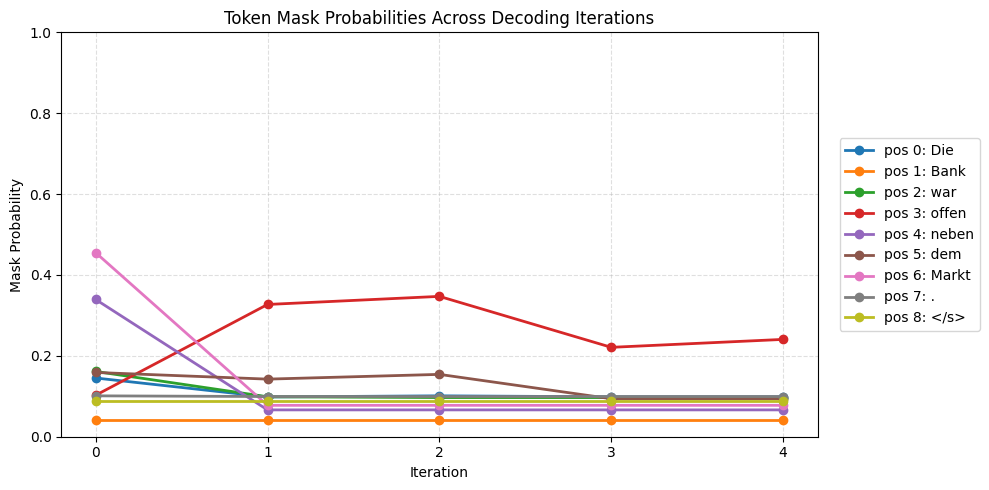

In [15]:
plot_token_mask_probs(decoder_patch_result)

In [16]:
print("final iteration mask probabilities:", decoder_patch_result["iteration_trace"][-1]["token_mask_probs"])


final iteration mask probabilities: [0.098687, 0.042573, 0.096882, 0.240678, 0.066347, 0.093917, 0.077642, 0.099397, 0.088161]


In [17]:
tracked_token_position = 1
tracked_token_id = decoded_original_tgt["token_ids"][tracked_token_position]
tracked_token_text = context["task"].target_dictionary[tracked_token_id]

print("tracked token position:", tracked_token_position)
print("tracked token in original target decode:", tracked_token_text)
print("original target decode:", decoded_original_tgt["decoded_text"])


tracked token position: 1
tracked token in original target decode: Bank
original target decode: Die Bank war neben dem Markt offen .


In [18]:
layer_sweep_result = run_decoder_layer_sweep_experiment(
    donor_sentence=patch_src_sentence,
    base_sentence=patch_tgt_sentence,
    context=context,
    tracked_token_position=tracked_token_position,
    decoding_iterations=5,
)


In [19]:
print("layerwise decoder patching results:")
for layer_result in layer_sweep_result["layer_results"]:
    print(f"layer {layer_result['layer_index']}: {layer_result['decoded_text']}")
    print("  tracked token texts by iteration:", layer_result["tracked_token_texts_by_iteration"])
    print("  tracked token mask probs:", layer_result["tracked_token_mask_probs"])


layerwise decoder patching results:
layer 0: Die Bank war neben neben dem Markt .
  tracked token texts by iteration: ['Bank', 'Bank', 'Bank', 'Bank', 'Bank']
  tracked token mask probs: [0.067618, 0.067618, 0.067618, 0.067618, 0.067618]
layer 1: Die Bank war offen neben dem Markt .
  tracked token texts by iteration: ['Bank', 'Bank', 'Bank', 'Bank', 'Bank']
  tracked token mask probs: [0.051259, 0.051259, 0.051259, 0.051259, 0.051259]
layer 2: Die Bank war offen neben dem Markt .
  tracked token texts by iteration: ['Bank', 'Bank', 'Bank', 'Bank', 'Bank']
  tracked token mask probs: [0.042573, 0.042573, 0.042573, 0.042573, 0.042573]
layer 3: Die Bank war offen neben dem Markt .
  tracked token texts by iteration: ['Bank', 'Bank', 'Bank', 'Bank', 'Bank']
  tracked token mask probs: [0.033669, 0.033669, 0.033669, 0.033669, 0.033669]
layer 4: Die Bank war offen neben dem Markt .
  tracked token texts by iteration: ['Bank', 'Bank', 'Bank', 'Bank', 'Bank']
  tracked token mask probs: [0.04

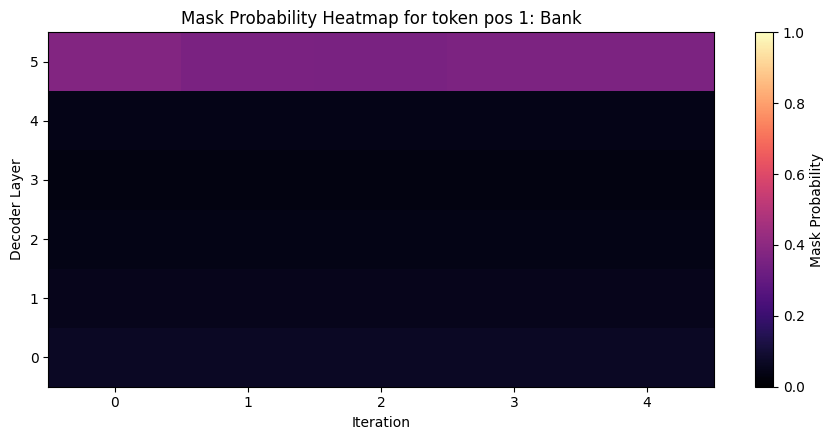

In [20]:
plot_layerwise_token_mask_heatmap(layer_sweep_result)
